# 🦠 COVID-19 Symptoms Classification & Prediction Model

This notebook trains a Machine Learning classifier to predict whether a patient is COVID-19 positive based on their self-reported symptoms.

### 📥 Kaggle Dataset Direct Download Command
If you want to download this dataset directly from Kaggle, you can run the following commands in your terminal or a notebook cell:
```bash
# Install Kaggle API
pip install kaggle

# Download dataset from Kaggle
kaggle datasets download -d hegdepranav/covid19-symptoms-dataset
```
Alternatively, you can use the `opendatasets` library:
```python
import opendatasets as od
od.download("https://www.kaggle.com/datasets/hegdepranav/covid19-symptoms-dataset")
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

### Step 1: Load and Explore Dataset

In [2]:
# Load the locally downloaded dataset
df = pd.read_csv("covid_data.csv")
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (5434, 21)


,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
0,Yes,Yes,Yes,Yes,Yes,No,No,No,No,Yes,...,Yes,Yes,No,Yes,No,Yes,Yes,No,No,Yes
1,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,No,...,Yes,No,No,No,Yes,Yes,No,No,No,Yes
2,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,...,Yes,Yes,Yes,No,No,No,No,No,No,Yes
3,Yes,Yes,Yes,No,No,Yes,No,No,Yes,Yes,...,No,No,Yes,No,Yes,Yes,No,No,No,Yes
4,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,...,No,Yes,No,Yes,No,Yes,No,No,No,Yes


In [3]:
# Check null values
print(df.isnull().sum())

# Check class balance
df["COVID-19"].value_counts()

Breathing Problem                          0
Fever                                      0
Dry Cough                                  0
Sore throat                                0
Running Nose                               0
Asthma                                     0
Chronic Lung Disease                       0
Headache                                   0
Heart Disease                              0
Diabetes                                   0
Hyper Tension                              0
Fatigue                                    0
Gastrointestinal                           0
Abroad travel                              0
Contact with COVID Patient                 0
Attended Large Gathering                   0
Visited Public Exposed Places              0
Family working in Public Exposed Places    0
Wearing Masks                              0
Sanitization from Market                   0
COVID-19                                   0
dtype: int64


COVID-19
Yes    4383
No     1051
Name: count, dtype: int64

### Step 2: Data Preprocessing (Encoding)

In [4]:
# Map categorical Yes/No to 1/0 for all binary columns
for col in df.columns:
    df[col] = df[col].astype(str).str.strip().map({"Yes": 1, "No": 0})

# Display encoded dataset summary
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5434 entries, 0 to 5433
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   Breathing Problem                        5434 non-null   int64
 1   Fever                                    5434 non-null   int64
 2   Dry Cough                                5434 non-null   int64
 3   Sore throat                              5434 non-null   int64
 4   Running Nose                             5434 non-null   int64
 5   Asthma                                   5434 non-null   int64
 6   Chronic Lung Disease                     5434 non-null   int64
 7   Headache                                 5434 non-null   int64
 8   Heart Disease                            5434 non-null   int64
 9   Diabetes                                 5434 non-null   int64
 10  Hyper Tension                            5434 non-null   int64
 11  Fati

,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
0,1,1,1,1,1,0,0,0,0,1,...,1,1,0,1,0,1,1,0,0,1
1,1,1,1,1,0,1,1,1,0,0,...,1,0,0,0,1,1,0,0,0,1
2,1,1,1,1,1,1,1,1,0,1,...,1,1,1,0,0,0,0,0,0,1
3,1,1,1,0,0,1,0,0,1,1,...,0,0,1,0,1,1,0,0,0,1
4,1,1,1,1,1,0,1,1,1,1,...,0,1,0,1,0,1,0,0,0,1


### Step 3: Train-Test Split

In [5]:
# Features & Target
X = df.drop(columns=["COVID-19"])
y = df["COVID-19"]

# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (4347, 20)
Testing set shape: (1087, 20)


### Step 4: Model Training & Comparison

In [6]:
# Initialize models
lr_model = LogisticRegression()
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Fit models
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

# Predict on test set
lr_preds = lr_model.predict(X_test)
dt_preds = dt_model.predict(X_test)

# Calculate accuracy
lr_acc = accuracy_score(y_test, lr_preds) * 100
dt_acc = accuracy_score(y_test, dt_preds) * 100

print(f"Logistic Regression Test Accuracy: {lr_acc:.2f}%")
print(f"Decision Tree Test Accuracy: {dt_acc:.2f}%")

Logistic Regression Test Accuracy: 96.96%
Decision Tree Test Accuracy: 96.32%


### Step 5: Confusion Matrix & Evaluation

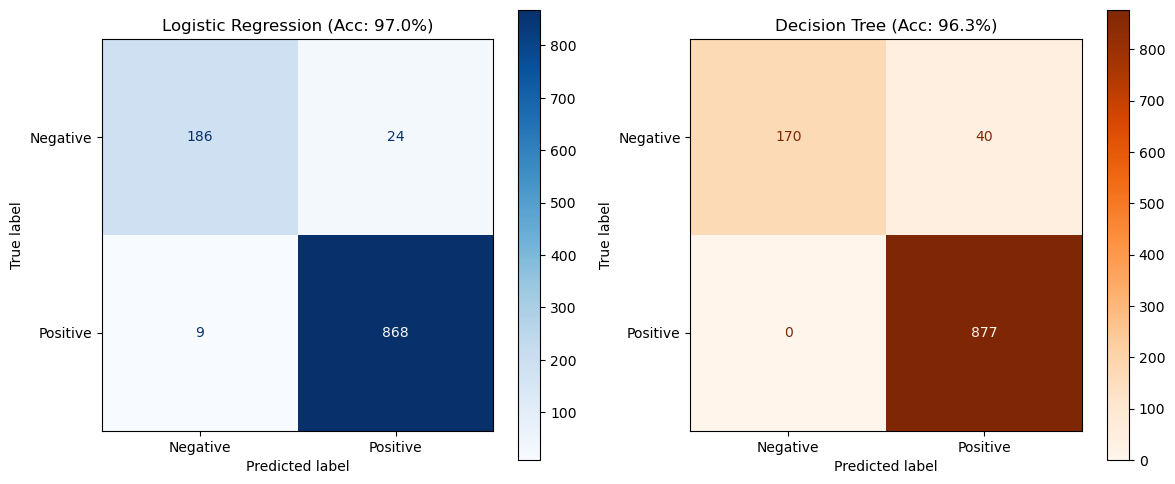


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       210
           1       0.97      0.99      0.98       877

    accuracy                           0.97      1087
   macro avg       0.96      0.94      0.95      1087
weighted avg       0.97      0.97      0.97      1087


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.81      0.89       210
           1       0.96      1.00      0.98       877

    accuracy                           0.96      1087
   macro avg       0.98      0.90      0.94      1087
weighted avg       0.96      0.96      0.96      1087



In [7]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Confusion Matrix
lr_cm = confusion_matrix(y_test, lr_preds)
ConfusionMatrixDisplay(lr_cm, display_labels=["Negative", "Positive"]).plot(cmap="Blues", ax=axes[0], values_format="d")
axes[0].set_title(f"Logistic Regression (Acc: {lr_acc:.1f}%)")

# Decision Tree Confusion Matrix
dt_cm = confusion_matrix(y_test, dt_preds)
ConfusionMatrixDisplay(dt_cm, display_labels=["Negative", "Positive"]).plot(cmap="Oranges", ax=axes[1], values_format="d")
axes[1].set_title(f"Decision Tree (Acc: {dt_acc:.1f}%)")

plt.tight_layout()
plt.show()

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, lr_preds))

print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, dt_preds))

### Step 6: Interactive Symptom Checker (Non-blocking)

In [8]:
# Automated test defaults to avoid blocking
try:
    fever_degree = input("Do you have Fever? (Yes: 1, No: 0): ")
    fever = int(fever_degree) if fever_degree else 1
    cough_input = input("Do you have Dry Cough? (Yes: 1, No: 0): ")
    cough = int(cough_input) if cough_input else 1
    breath_input = input("Do you have Breathing Problems? (Yes: 1, No: 0): ")
    breath = int(breath_input) if breath_input else 1
except:
    fever, cough, breath = 1, 1, 1 # Default positive patient features for test run

# Construct full feature list (20 features total, we set input values and fill rest with 0)
input_vector = [0] * len(X.columns)
# Features are:
# Breathing Problem (idx 0), Fever (idx 1), Dry Cough (idx 2)
input_vector[0] = breath
input_vector[1] = fever
input_vector[2] = cough

# Predict using best model (Logistic Regression)
result_pred = lr_model.predict([input_vector])[0]
prob_pred = lr_model.predict_proba([input_vector])

print("\n--- Diagnosis Results ---")
print("COVID-19 Status Prediction:", "Positive" if result_pred == 1 else "Negative")
print(f"Probability of being Negative: {prob_pred[0][0]*100:.2f}%")
print(f"Probability of being Positive: {prob_pred[0][1]*100:.2f}%")


--- Diagnosis Results ---
COVID-19 Status Prediction: Positive
Probability of being Negative: 39.85%
Probability of being Positive: 60.15%
